In [4]:
import pandas as pd
import os
import requests
import json

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [6]:
from preprocessing_utils import preprocess_NVD_data

In [7]:
data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# EPSS data

Download the EPSS data from https://www.first.org/epss/data_stats into `data` folder

### <font color='blue'><b><i>TODO</i></b></font>:
- in the following cell, replace `epss_scores-2025-09-30.csv.gz` with the correct updated file (`epss_scores-2025-10-01.csv.gz`)

In [8]:
epss_current = pd.read_csv(os.path.join(data_path, 'epss_scores-2025-10-05.csv.gz'), compression='gzip', header=1)
epss_current # a Python statement with a variable name at the end of a cell will display its contents below


,cve,epss,percentile
0,CVE-1999-0001,0.01076,0.77053
1,CVE-1999-0002,0.15339,0.94381
2,CVE-1999-0003,0.90362,0.99577
3,CVE-1999-0004,0.03215,0.86538
4,CVE-1999-0005,0.25334,0.96002
...,...,...,...
296849,CVE-2025-9994,0.00063,0.20046
296850,CVE-2025-9996,0.00179,0.39898
296851,CVE-2025-9997,0.00182,0.40254
296852,CVE-2025-9998,0.00023,0.04721


# NVD data

In [9]:
base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
date_start_NVD = '2025-09-01T00:00:00.000Z' # Do NOT change these dates
date_end_NVD   = '2025-10-01T00:00:00.000Z' # Do NOT change these dates
start_index = 0
results_per_page = 1000
total_results = 1 

all_cves = []

while start_index < total_results:
    params = {
        "pubStartDate": date_start_NVD,
        "pubEndDate": date_end_NVD,
        "resultsPerPage": results_per_page,
        "startIndex": start_index,
        "noRejected": ""
    }
    response = requests.get(base_url, params=params, timeout=6)
    if response.status_code != 200:
        print("Error:", response.status_code)
        break

    data = response.json()
    total_results = data.get("totalResults", 0)

    all_cves.extend(data.get("vulnerabilities", []))

    start_index += results_per_page
    print(start_index)

1000
2000
3000
4000
5000


In [10]:
# normalize and preprocess data
df = pd.json_normalize(all_cves, record_path=None, sep='.', max_level=None)
df = preprocess_NVD_data(df)

# remove vulnerabilities marked as "reject" or "reserved"
df = df[(df['cve.vulnStatus']!='Reserved') & (df['cve.vulnStatus']!='Reject')]

# merge NVD and EPSS data
df = df.merge(epss_current, left_on="cve.id", right_on="cve", how="left")

In [11]:
# save nvd data
with open(os.path.join(data_path, "nvd_cves.json"), "w", encoding="utf-8") as f:
    json.dump(all_cves, f, indent=2)
    
# save the final dataframe
df.to_csv(os.path.join(data_path, "vuln_2025_10.csv"))

# Exploratory Data Analysis

- display some examples (e.g., the first two CVE records)

In [12]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2025-09-08 14:06:05.217000,2025-09-04 18:47:25.440000
cve.vulnStatus,Analyzed,Analyzed
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN
cve.cisaRequiredAction,NaN,NaN
cve.cisaVulnerabilityName,NaN,NaN


- show a bar plot with the daily volume of published CVEs

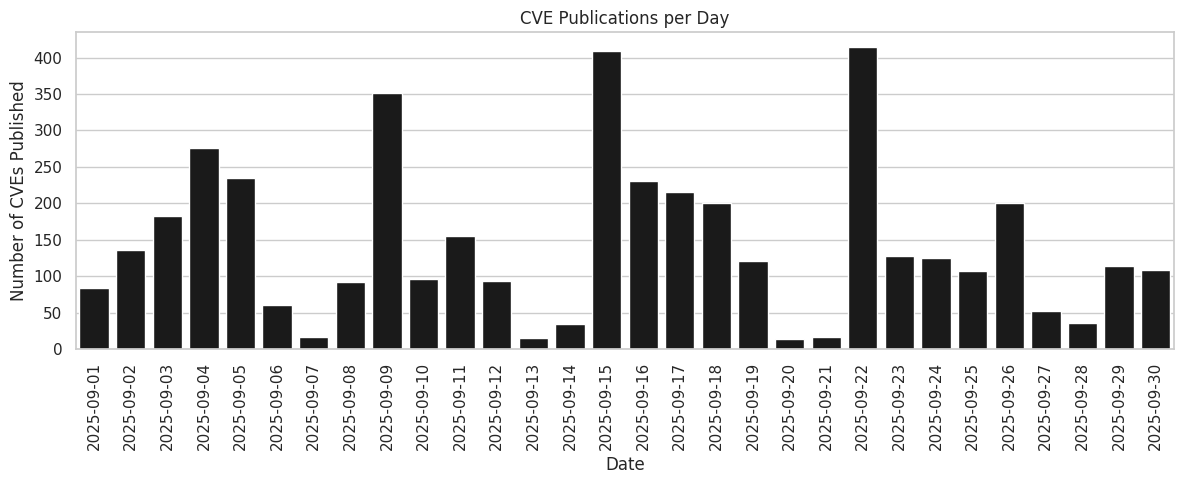

In [13]:
published_counts = df["cve.published"].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=published_counts.index, y=published_counts.values, color="k" )
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Number of CVEs Published")
plt.title("CVE Publications per Day")
plt.tight_layout()
plt.show()

In [14]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2025-09-08 14:06:05.217000,2025-09-04 18:47:25.440000
cve.vulnStatus,Analyzed,Analyzed
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN
cve.cisaRequiredAction,NaN,NaN
cve.cisaVulnerabilityName,NaN,NaN


- print the description of the last ten published vulnerabilities

In [15]:
for idx, x in enumerate(df.sort_values('cve.published', ascending=False)[:10].iterrows()):
    print('-'*100)
    print(x[1]['cve.id'], x[1]['cve.published'])
    print(x[1].description)


----------------------------------------------------------------------------------------------------
CVE-2025-61792 2025-09-30 23:15:29.700000
Quadient DS-700 iQ devices through 2025-09-30 might have a race condition during the quick clicking of (in order) the Question Mark button, the Help Button, the About button, and the Help Button, leading to a transition out of kiosk mode into local administrative access. NOTE: the reporter indicates that the "behavior was observed sporadically" during "limited time on the client site," making it not "possible to gain more information about the specific kiosk mode crashing issue," and the only conclusion was "there appears to be some form of race condition." Accordingly, there can be doubt that a reproducible cybersecurity vulnerability was identified; sporadic software crashes can also be caused by a hardware fault on a single device (for example, transient RAM errors). The reporter also describes a variety of other issues, including initial acc

### <font color='blue'><b><i>TODO</i></b>: produce plots or tables to address the folowing points</font>
- what is the percentage of CVEs which received a CVSS score?
- report descriptive statistics of CVSS the CVSS base score and/or show its distribution
- report descriptive statistics of EPSS and/or show its distribution
- produce a scatter plot showing CVSS vs EPSS
- <b>be creative</b>!
    - How many vulnerabilities are published on CISA KEV? 
    - What are the the 20 most frequent vendors? (vendor name can be extracted from the `vulnerable_cpes` field).
    - What are the 20 most frequent CWEs?
    - Anaything else you see fit!

<font color='blue'>Use text cells to discuss the outcome after each point</font>

# Percetage of CVE with score

I think the number of the CVE with no score is quite relevant because one serious vulnarbility is enough to make a lot of damgage, damage is indicative because we need to consider: 
- which type of device can be affected
- the difficulty to exploit the vulerability
- if need privilege
- the need a user autentication

percetage with no score 0.13211476168440536


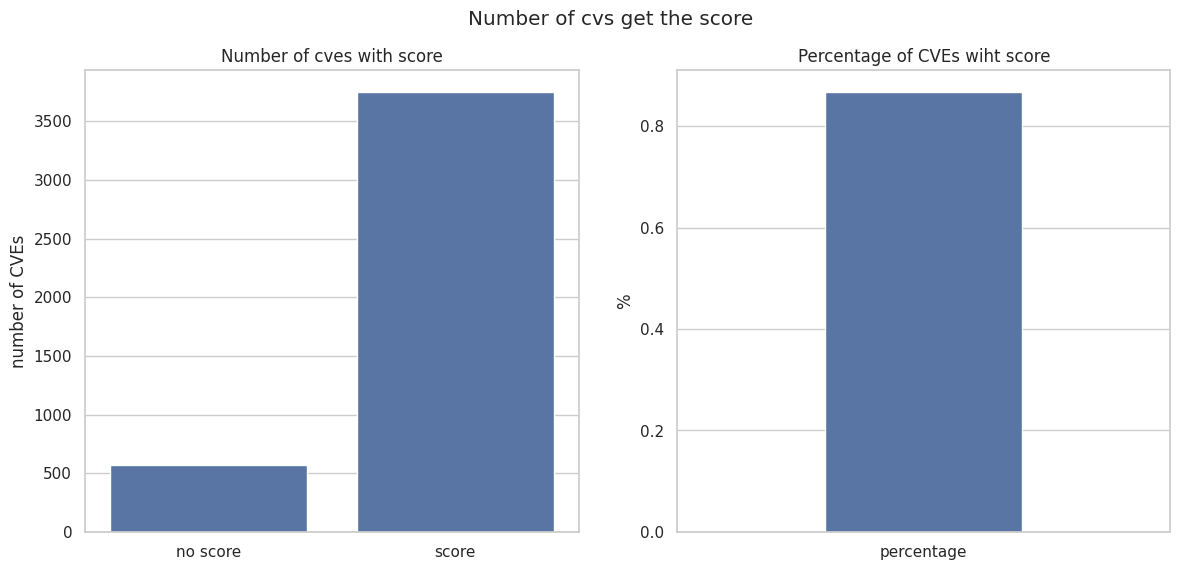

In [16]:
from matplotlib import pyplot as plt

no_score = df["cvss_baseScore"].isnull().sum()
r,c = df.shape

var = {"no score":no_score,"score":r-no_score}

print(f"percetage with no score {no_score/r}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.suptitle("Number of cvs get the score")
sns.barplot(var, ax = ax1)
ax1.set_title("Number of cves with score")
ax1.set_ylabel("number of CVEs")

score = {"percentage":(1-no_score/r)}

sns.barplot(score ,ax = ax2)
ax2.set_title("Percentage of CVEs wiht score")
ax2.set_ylabel("%")
for patch in ax2.patches:
    patch.set_width(0.4)
    patch.set_x(patch.get_x()+0.2)




# CVSS basescore analisys

The distribution of cvs basescore reach the peak a little bit over 6 and it means that most of the CVEs are dangerous. Dangerous in terms of gather info of the network structure,gather privileges or personal data etc...

Text(0, 0.5, 'Number of cvss')

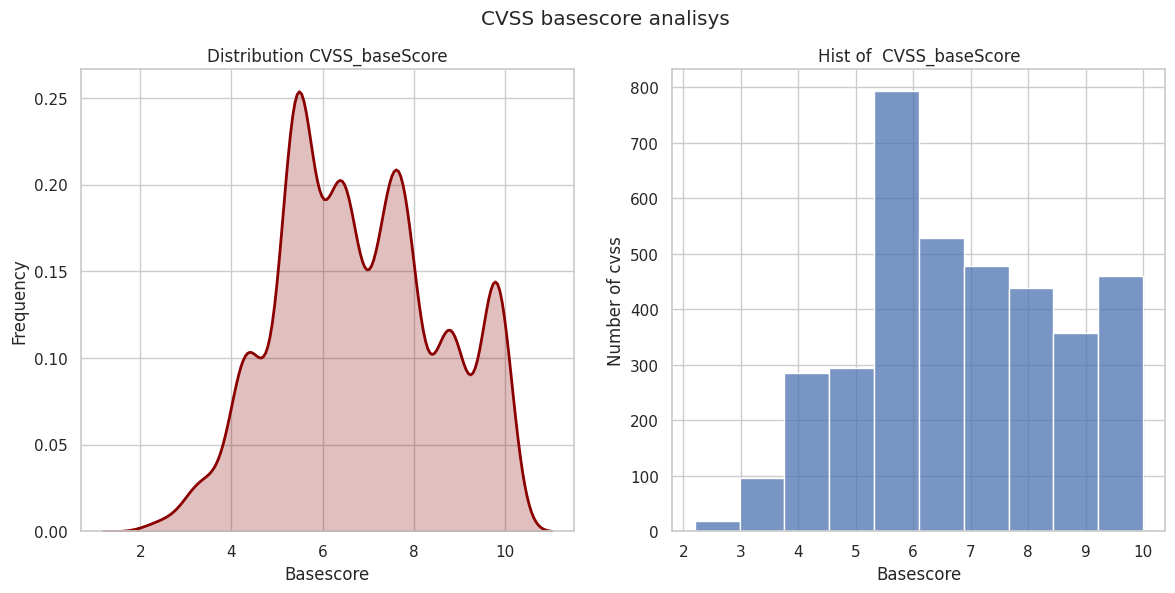

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.suptitle("CVSS basescore analisys")


sns.kdeplot(df['cvss_baseScore'], fill=True, linewidth=2, color='darkred',ax=ax1)
ax1.set_title('Distribution CVSS_baseScore')
ax1.set_xlabel("Basescore")
ax1.set_ylabel("Frequency")

sns.histplot(df['cvss_baseScore'],bins=10, ax=ax2)
ax2.set_title('Hist of  CVSS_baseScore')
ax2.set_xlabel("Basescore")
ax2.set_ylabel("Number of cvss")

# EPSS Analysis
Almost all of the CVEs have an EPSS that don't go over the 0.1 treshold, so I zommed inside the window beetwen 0 and 0.002 to see somethig in detail and make the graph more pretty. But we are talking about percentage of cve to be exploited so the centesimal part of the EPSS don't make differnce in reality.
The CVEs that goes over 0.1 are a few, so who is in charge to patch the targeted CVEs knows which one need more attention.


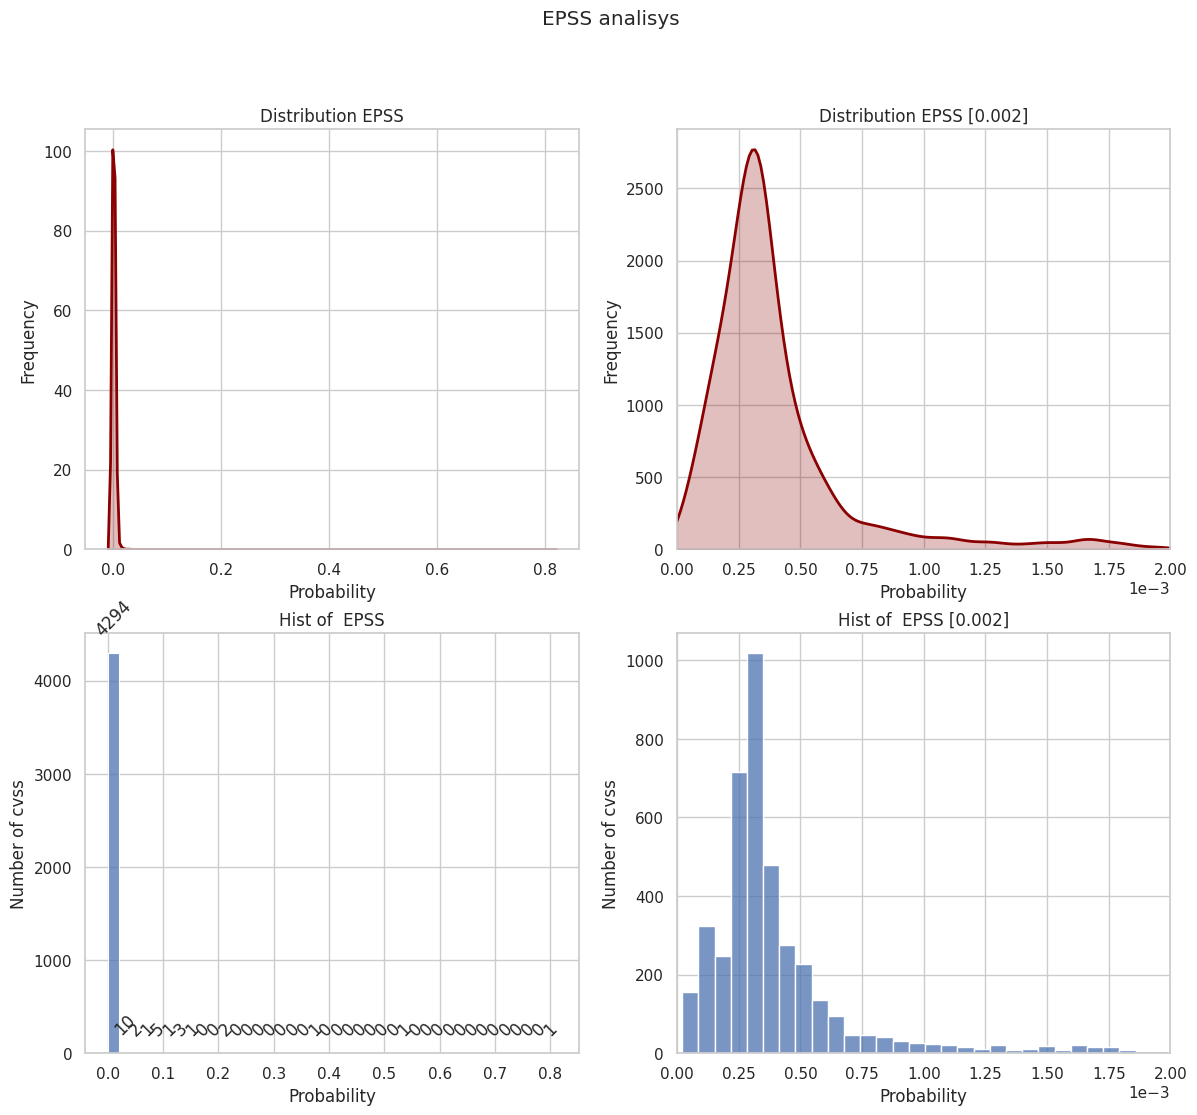

In [18]:
zoom = 0.002

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.suptitle("EPSS analisys")

ax = axes[0,0]
sns.kdeplot(df['epss'], fill=True, linewidth=2, color='darkred',ax=ax)
ax.set_title('Distribution EPSS')
ax.set_xlabel("Probability")
ax.set_ylabel("Frequency")

ax = axes[0,1]
sns.kdeplot(df['epss'].where(df['epss']<zoom), fill=True, linewidth=2, color='darkred',ax=ax)
ax.set_title(f'Distribution EPSS [{zoom}]')
ax.set_xlabel("Probability")
ax.set_ylabel("Frequency")
ax.set_xbound(0,zoom)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))


ax = axes[1,0]
sns.histplot(df['epss'],bins=40, ax=ax)
ax.set_title('Hist of  EPSS')
ax.set_xlabel("Probability")
ax.set_ylabel("Number of cvss")
ax.bar_label(ax.containers[0], rotation = 45, padding=10)

ax = axes[1,1]
sns.histplot(df['epss'].where(df['epss']<zoom),bins=30, ax=ax)
ax.set_title(f'Hist of  EPSS [{zoom}]')
ax.set_xlabel("Probability")
ax.set_ylabel("Number of cvss")
ax.set_xbound(0,zoom)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

# CVSS vs EPSS

As we can see fo the first graph a lot of CVEs don't have an high epss, but if we put a regression line we can see there is a trend to which with high cve we can get high epss. The truncated graph doesn't consider point outside the range written (like noise) instead the zoomed graph does. The zoomed one has more incline line and has more variation. The two lines are different but the trend still remain the only diffenrce is in the fourth it is more accentuated.

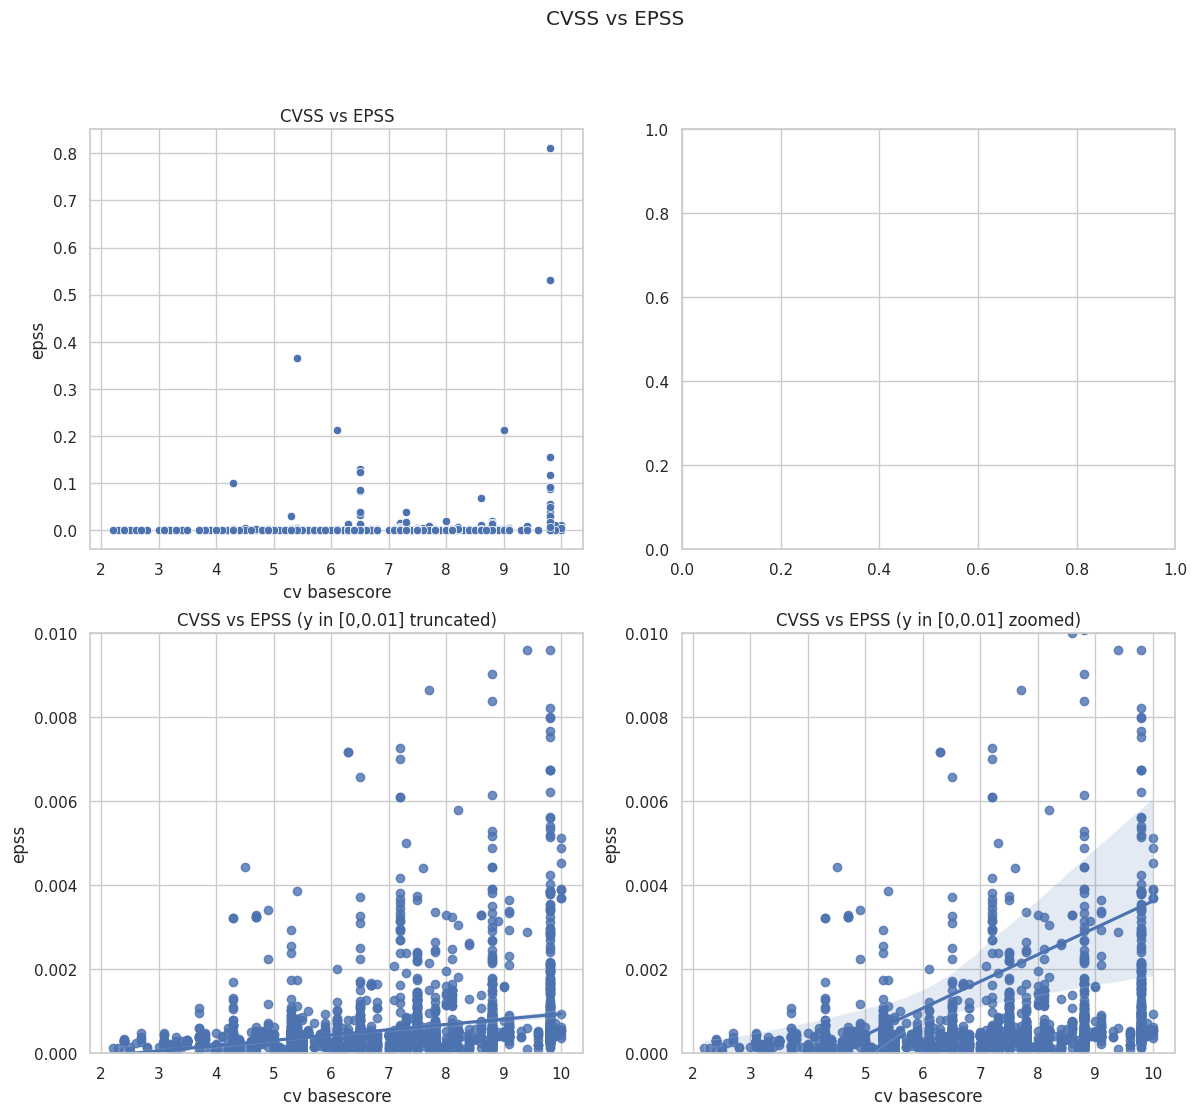

In [19]:
data = {
    "x" : df['cvss_baseScore'],
    "y" : df['epss'],
    "Label" : ["CVSS","EPSS"]
} 


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.suptitle("CVSS vs EPSS")

ax = axes[0][0]
sns.scatterplot(x="x", y = "y", data=data,ax=ax)
ax.set_title('CVSS vs EPSS')
ax.set_xlabel("cv basescore")
ax.set_ylabel("epss")

ax = axes[1][1]
sns.regplot(x="x", y = "y", data=data,ax=ax, order=1)
ax.set_title('CVSS vs EPSS (y in [0,0.01] zoomed)')
ax.set_xlabel("cv basescore")
ax.set_ylabel("epss")
ax.set_ybound(0,0.01)

data["y"] = data["y"].where(data["y"]<0.01)
ax = axes[1][0]
sns.regplot(x="x", y = "y", data=data,ax=ax, order=1)
ax.set_title('CVSS vs EPSS (y in [0,0.01] truncated)')
ax.set_xlabel("cv basescore")
ax.set_ylabel("epss")
ax.set_ybound(0,0.01)



# CVE selection


### <font color='blue'><b><i>TODO</i></b>
- Filter the CVEs with low EPSS (<1%)
- Select candidate CVEs
    - From the resulting subset, select 10 CVEs that you think will reach high EPSS by the end of the course.
    - Clearly describe the criteria you used for selection (e.g., high CVSS, popular software, CWE, popular vendor, number of references, keyword in description, manual inspection, random sampling, security blogs).
- Share the selected CVE ids with the instructor (by two weeks). Use the code cell below to produce the csv file to submit.
- Track the EPSS of your CVEs over time


# Filter dataset

I'm going to consider only rows with epss < 0.01

In [45]:
print(df.shape[0])
df_possible = df[df["epss"]<0.01]
print(df_possible.shape[0])

4322
4267


# 1. Decision

if a cve fall in more cwe can affect more type of device, 
I took the one with a maxinum number of cwe
and I filter df to consider cve with more than 2 cwe


In [46]:
#filter by count of cwe
#if it can be in multiple field can do more damage
#one from this

df_possible['cwe_count'] = df_possible['cwe_list'].apply(len)

df_possible['cwe_count'].max()
df_possible = df_possible[df_possible['cwe_count'] >2]
print(df_possible.shape[0])
cve_choose = df_possible[df_possible['cwe_count'] == df_possible['cwe_count'].max()]
cve_choose.shape

205


/tmp/ipykernel_20291/3923971648.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_possible['cwe_count'] = df_possible['cwe_list'].apply(len)


(1, 30)

# 2. Decision

Consider the only ones with all the of Impact equals to HIGH and shrinked the df 
I tried to filter with cvss_scope equal to changed but i got only on result i pick it and relaxed the constraint

In [47]:
#all problems high that has been changed -> something is goin on
# another one got it
print(df_possible["cvss_scope"].unique())
cond1 = (df_possible["cvss_integrityImpact"] == "HIGH")
cond2 = (df_possible["cvss_availabilityImpact"] == "HIGH")
cond3 = (df_possible["cvss_confidentialityImpact"] == "HIGH")
cond4 = (df_possible["cvss_scope"] == "CHANGED")
cond5 = (df_possible["cvss_scope"] != "CHANGED")
cond =  cond1 & cond2 & cond3 & cond4

row_count = cond.sum()
print(row_count)

filtered_rows = df_possible[cond]
cve_choose = pd.concat([cve_choose,filtered_rows], ignore_index=True)
cond =  cond1 & cond2 & cond3 & cond5
df_possible = df_possible[cond]
df_possible.shape[0]

['UNCHANGED' 'CHANGED']
1


133

# 3. Decision

I tried to find is some CVEs was modified so maybe it's going to be a nww threat
Bad luck this time

In [48]:
#get the ones that need action in time
# got one this time
print(df_possible["cve.vulnStatus"].unique())
cond1 = (df_possible["cve.vulnStatus"] == "Modified")
cond2 = (df_possible["cve.vulnStatus"] != "Modified")

cond = cond1

row_count = cond.sum()

print(row_count)


filtered_rows = df_possible[cond]
cve_choose = pd.concat([cve_choose,filtered_rows], ignore_index=True)
cond =  cond2
df_possible = df_possible[cond]
df_possible.shape[0]

['Analyzed' 'Modified']
2


131

# 4. Decision

Consider the more dangerous ones by che cvss basescore

In [49]:
#get cve with the most cvss score
print(df_possible.shape[0])
df_possible = df_possible[df_possible['cvss_baseScore'] == df_possible['cvss_baseScore'].max() ]
df_possible.shape[0]

131


95

# 5. Decision

Fill the remaining slots with the most recent modified CVEs

In [50]:
#finished the idea so get the last modified cves for the remaining position
df_sorted_asc = df_possible.sort_values(by='cve.lastModified', ascending=False)

print(cve_choose.shape[0])
cve_choose = pd.concat([cve_choose,df_sorted_asc.head(10-cve_choose.shape[0])], ignore_index=True)
print(cve_choose.shape[0])


4
10


# Make sure is all corect without dubplicate

In [51]:

cve_choose.shape[0]

cve_choose = cve_choose.drop('cwe_list', axis=1)
cve_choose = cve_choose.drop('cve.references', axis=1)
cve_choose = cve_choose.drop('vulnerable_cpes', axis=1)

cve_choose = cve_choose.drop_duplicates()


cve_choose[["cve","epss"]]

,cve,epss
0,CVE-2025-55118,0.00050
1,CVE-2025-57644,0.00366
2,CVE-2025-57807,0.00031
3,CVE-2025-10773,0.00093
4,CVE-2025-10103,0.00030
5,CVE-2025-10477,0.00029
6,CVE-2025-11052,0.00037
7,CVE-2025-34196,0.00031
8,CVE-2025-10218,0.00029
9,CVE-2025-59834,0.00354


In [52]:
nickname = "hifodbs"  # TODO: put your nickname here


# TODO: put your selected IDs here
selected = [
    "CVE-2025-55118",
    "CVE-2025-57644",
    "CVE-2025-10773",
    "CVE-2025-11032",
    "CVE-2025-11033",
    "CVE-2025-11035",
    "CVE-2025-10768",
    "CVE-2025-10769",
    "CVE-2025-10771",
    "CVE-2025-10597",
]

df[df["cve.id"].isin(selected)].to_csv(os.path.join(data_path, f"{nickname}.csv"))